In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [5]:
df = pd.read_csv('/content/Internship_Tasks/Cardiac Patient Monitoring System/data/heart_disease_uci.csv')

In [6]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


#### Data Dictionary

| Column | Description |
|---|---|
| `id` | Patient ID |
| `age` | Patient's age |
| `sex` | Patient's sex |
| `dataset` | Dataset or location where the data was collected |
| `cp` | Type of chest pain |
| `trestbps` | Resting blood pressure |
| `chol` | Cholesterol level |
| `fbs` | Whether fasting blood sugar is greater than 120 mg/dL |
| `restecg` | Resting electrocardiogram (ECG) result |
| `thalch` | Maximum heart rate achieved |
| `exang` | Whether exercise-induced angina occurs |
| `oldpeak` | ST depression during exercise compared with rest |
| `slope` | Slope of the ST segment during exercise |
| `ca` | Number of major vessels colored by fluoroscopy |
| `thal` | Thalassemia test result |
| `num` | Presence/severity of heart disease — target variable |

In [7]:
df.drop('id',axis=1,inplace=True)

Before modeling, we visualize every numeric and categorical column to
understand distributions, class balance, and potential data-quality
issues (missing values are common in this dataset, especially in the
later-added hospital sources).

In [8]:
numeric_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
categorical_cols = ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'num']

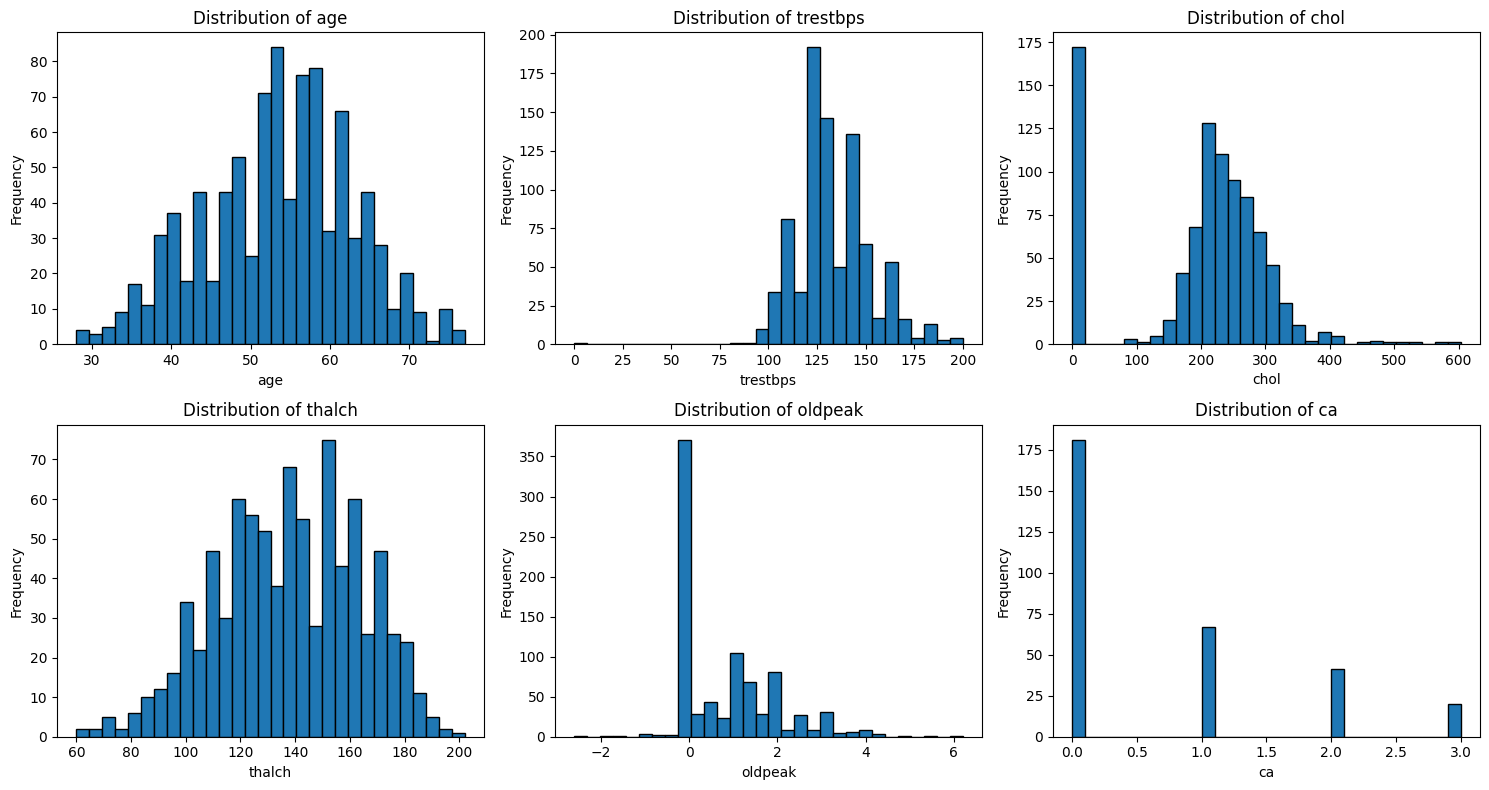

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=30, edgecolor='black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### Numeric Feature Distributions

- **`age`**: Roughly bell-shaped, centered around 55-60, ranging from
  ~28 to ~77 — a realistic adult patient population with no obvious
  outliers.
- **`trestbps`** (resting blood pressure): Mostly concentrated between
  100-150, with a long right tail up to ~200. A few near-zero values are
  visible — likely invalid/missing data encoded as 0, which will need
  cleaning.
- **`chol`** (cholesterol): Shows a **suspicious spike at 0**, which is
  clinically impossible (cholesterol can't be zero) — this is almost
  certainly missing data encoded as 0 rather than NaN, and needs to be
  treated as missing before analysis. Excluding that spike, the real
  distribution is roughly normal, centered around 200-250.
- **`thalch`** (max heart rate achieved): Roughly normal, centered around
  140-150, consistent with expected exercise heart rate ranges.
- **`oldpeak`** (ST depression): Heavily right-skewed with a large spike
  at 0 — most patients show no ST depression, with a smaller group
  showing moderate to high values (up to ~6). A few negative values are
  visible, which is unusual and worth double-checking.
- **`ca`** (number of major vessels colored by fluoroscopy): Not
  continuous — it takes only 4 discrete values (0, 1, 2, 3), with 0 being
  by far the most common. This is more like an ordinal/categorical
  variable despite being stored as numeric.

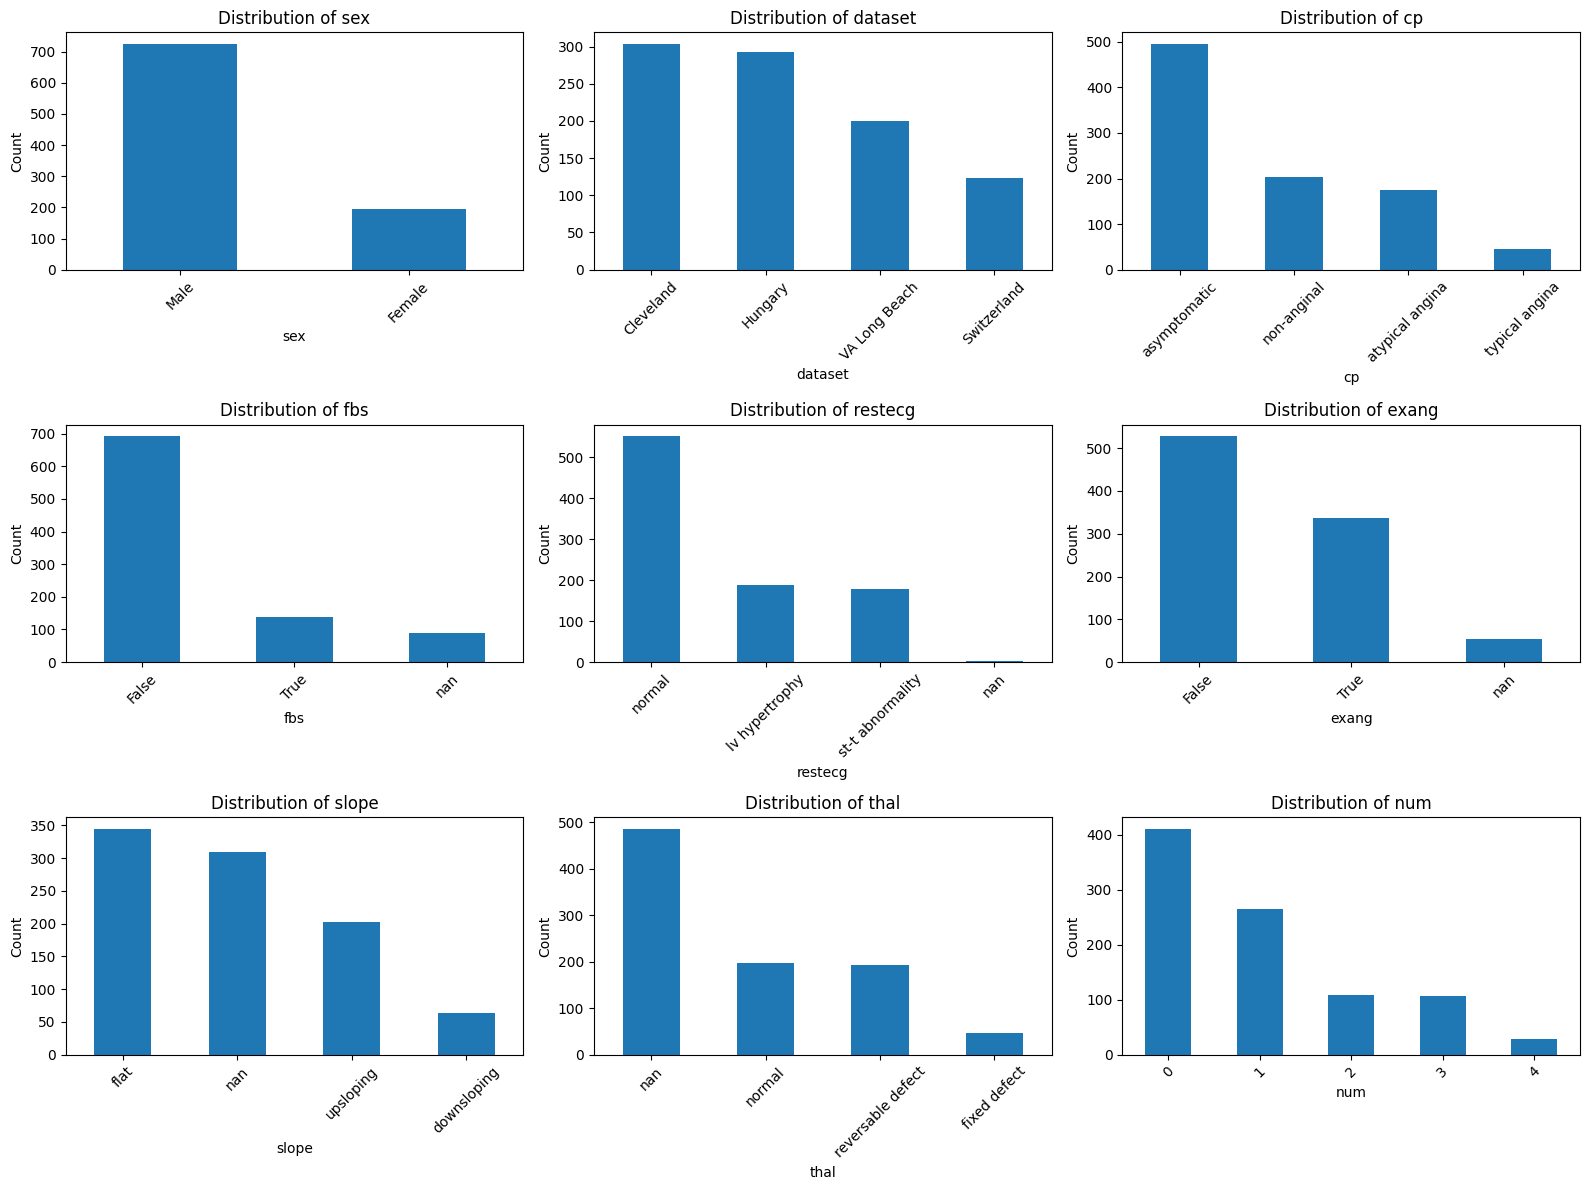

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    df[col].value_counts(dropna=False).plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Categorical Feature Distributions

**Demographics & Data Source:**
- **`sex`**: Strongly imbalanced — roughly 720 male vs. 190 female
  patients (~79% male). This imbalance should be kept in mind, as model
  performance may be less reliable for the underrepresented female group.
- **`dataset`**: Data comes from 4 hospitals (Cleveland, Hungary, VA Long
  Beach, Switzerland), with Cleveland and Hungary contributing the most
  records. Since data-quality varies by source (seen below), this column
  is useful for tracing where missing values originate.

**Clinical Indicators:**
- **`cp` (chest pain type)**: Most patients are asymptomatic (~500),
  which is somewhat counterintuitive — it reflects that this label means
  "no chest pain symptom reported," not "no disease."
- **`fbs` (fasting blood sugar)**: Mostly False (~700), meaning most
  patients do not have elevated fasting blood sugar. A small number of
  missing values (`nan`) are present.
- **`restecg`**: Mostly "normal" (~550), with meaningful numbers of "lv
  hypertrophy" and "st-t abnormality." Almost no missing values here.
- **`exang` (exercise-induced angina)**: Mostly False (~530), with
  moderate True cases (~340) — a reasonably balanced signal.
- **`slope`**: Roughly 300+ missing values (`nan`) — a substantial
  data-quality issue that will need to be addressed before modeling.
- **`thal`**: The **largest missing-value problem** in the dataset —
  "nan" is actually the *most frequent* category (~490 records),
  outnumbering all real categories combined. This column will need
  careful handling (imputation or exclusion).

**Target Variable (`num`):**
- Clearly **imbalanced across severity levels**: ~410 patients have no
  disease (0), while severity levels 1-4 progressively shrink (1: ~260,
  2: ~110, 3: ~110, 4: ~30). If treated as multiclass, levels 3 and 4 have
  very few samples — likely too few for reliable classification. This
  supports converting `num` into a **binary target** (0 = no disease,
  1+ = disease present) for a more robust classification problem.

In [11]:
df.isnull().sum()

,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55
exang,55


In [12]:
cols_to_impute = ['trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak','ca', 'thal', 'slope']

numeric_cols = df[cols_to_impute].select_dtypes(include='number').columns.tolist()
categorical_cols = df[cols_to_impute].select_dtypes(exclude='number').columns.tolist()

In [13]:
# Preprocessing for numeric columns: impute missing values with median
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# Preprocessing for categorical columns: impute with mode, then one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

In [15]:
df.isnull().sum()

,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55
exang,55


### Handling Missing Values

Missing values ranged widely across columns — from none in `age`, `sex`,
`dataset`, `cp`, and `num`, to just 2 in `restecg`, up to 611 (~66%) in
`ca`. Rather than dropping any columns, every column was imputed based on
its type: numeric columns (`trestbps`, `chol`, `fbs`, `thalch`, `exang`,
`oldpeak`, `slope`, `ca`) were filled with their median, robust against
outliers, while the categorical column `restecg` was filled with its mode,
since a median isn't meaningful for text categories like `normal` or
`lv hypertrophy`.

**Result:** all missing values are now filled, with the full dataset
preserved.

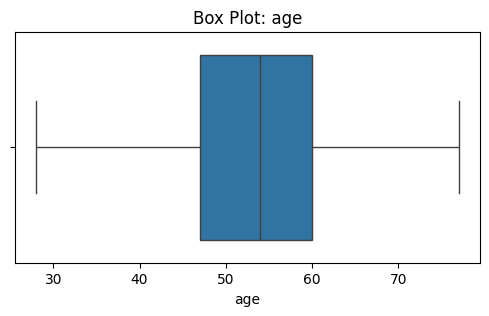

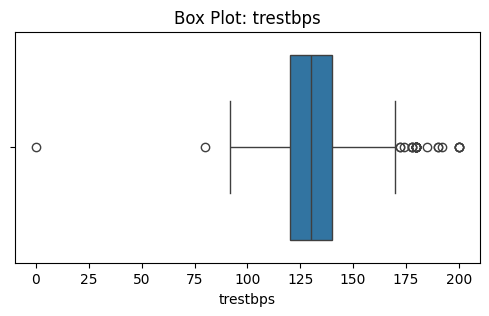

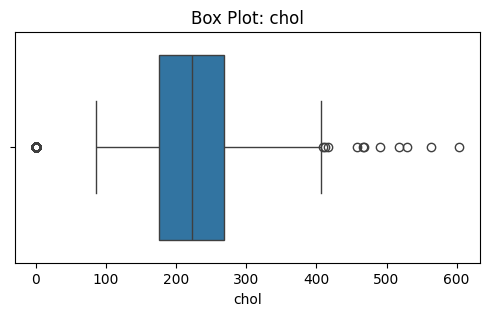

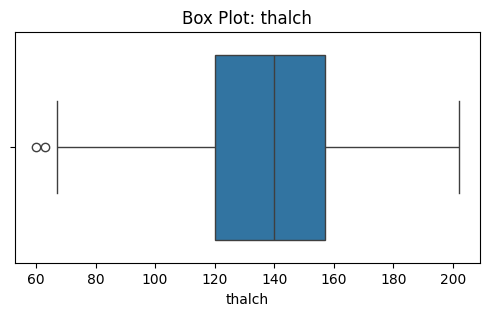

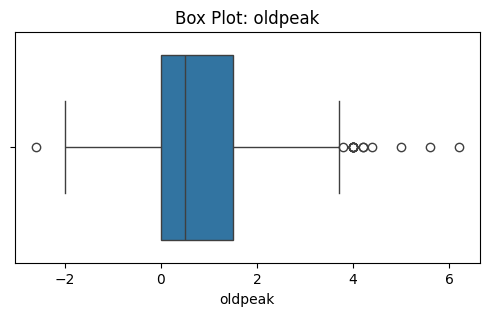

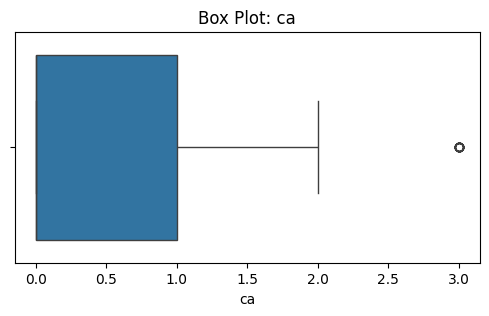

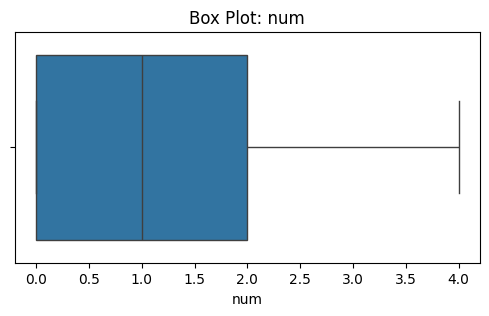

In [16]:
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"Box Plot: {col}")
    plt.show()

### Box Plot Findings: Numeric Columns

Scanning across all numeric columns reveals a clear pattern: most
distributions carry **outliers on the high end**, and one column shows a
value that isn't just an outlier — it's likely a data error.

- **`age`:** clean, no outliers.
- **`trestbps` (resting blood pressure):** several high outliers above
  ~170, plus **one value near 0** — a resting blood pressure of 0 isn't
  physiologically possible, so this is almost certainly a data-entry error
  rather than a genuine rare case.
- **`chol` (cholesterol):** a cluster of high outliers above ~400, and
  also **one value near 0**, the same likely error pattern as `trestbps`.
- **`thalch` (max heart rate):** a couple of low outliers near 60-70,
  otherwise clean — plausible for a genuinely low heart rate reading.
- **`oldpeak`:** several high outliers above ~4, plus one negative value —
  worth checking, since `oldpeak` (ST depression) is typically ≥0.
- **`ca`:** appears almost entirely one value (0), with a few points at
  1, 2, and 3 flagged as "outliers" — this is likely a discrete/count
  variable rather than continuous, so the IQR method isn't the right tool
  here.
- **`num`:** no outliers; this looks like the target variable (disease
  severity, 0-4), and its spread is expected, not anomalous.
  the zero values in `trestbps` and `chol` are the
real issue — they're implausible for a living patient and should be
treated as missing/invalid rather than genuine extreme values, then
handled the same way other missing data was (e.g. median imputation)
rather than left in as if they were real measurements.

In [17]:
# Delete zero rows with trestbps or chol (obvious data errors)
df = df[(df['trestbps'] != 0) & (df['chol'] != 0)]

print(df.shape)

(748, 15)


In [18]:
# Examine the existing category columns first.
categorical_cols = df.select_dtypes(exclude='number').columns.tolist()
print("Categorical columns:", categorical_cols)

for col in categorical_cols:
    print(f"\n{col}: {df[col].unique()}")

Categorical columns: ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

sex: ['Male' 'Female']

dataset: ['Cleveland' 'Hungary' 'VA Long Beach']

cp: ['typical angina' 'asymptomatic' 'non-anginal' 'atypical angina']

fbs: [True False nan]

restecg: ['lv hypertrophy' 'normal' 'st-t abnormality' nan]

exang: [False True nan]

slope: ['downsloping' 'flat' 'upsloping' nan]

thal: ['fixed defect' 'normal' 'reversable defect' nan]


Before encoding, we need to see exactly what text columns are present and what the unique values ​​are in each unit — because some columns (like `sex` or `cp`) may be simple binary, while other columns (`restecg`, `dataset`) have more than two classes and require one-hot encoding.

In [19]:
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(df.shape)
print(df.dtypes)

(748, 21)
age                           int64
trestbps                    float64
chol                        float64
thalch                      float64
oldpeak                     float64
ca                          float64
num                           int64
sex_Male                       bool
dataset_Hungary                bool
dataset_VA Long Beach          bool
cp_atypical angina             bool
cp_non-anginal                 bool
cp_typical angina              bool
fbs_True                       bool
restecg_normal                 bool
restecg_st-t abnormality       bool
exang_True                     bool
slope_flat                     bool
slope_upsloping                bool
thal_normal                    bool
thal_reversable defect         bool
dtype: object


The categorical (text) columns were converted to digital columns using one-hot encoding, with `drop_first=True` to avoid redundancy between categories (multicollinearity). This made every column in the dataset fully digital and ready for immediate use in any machine learning model.

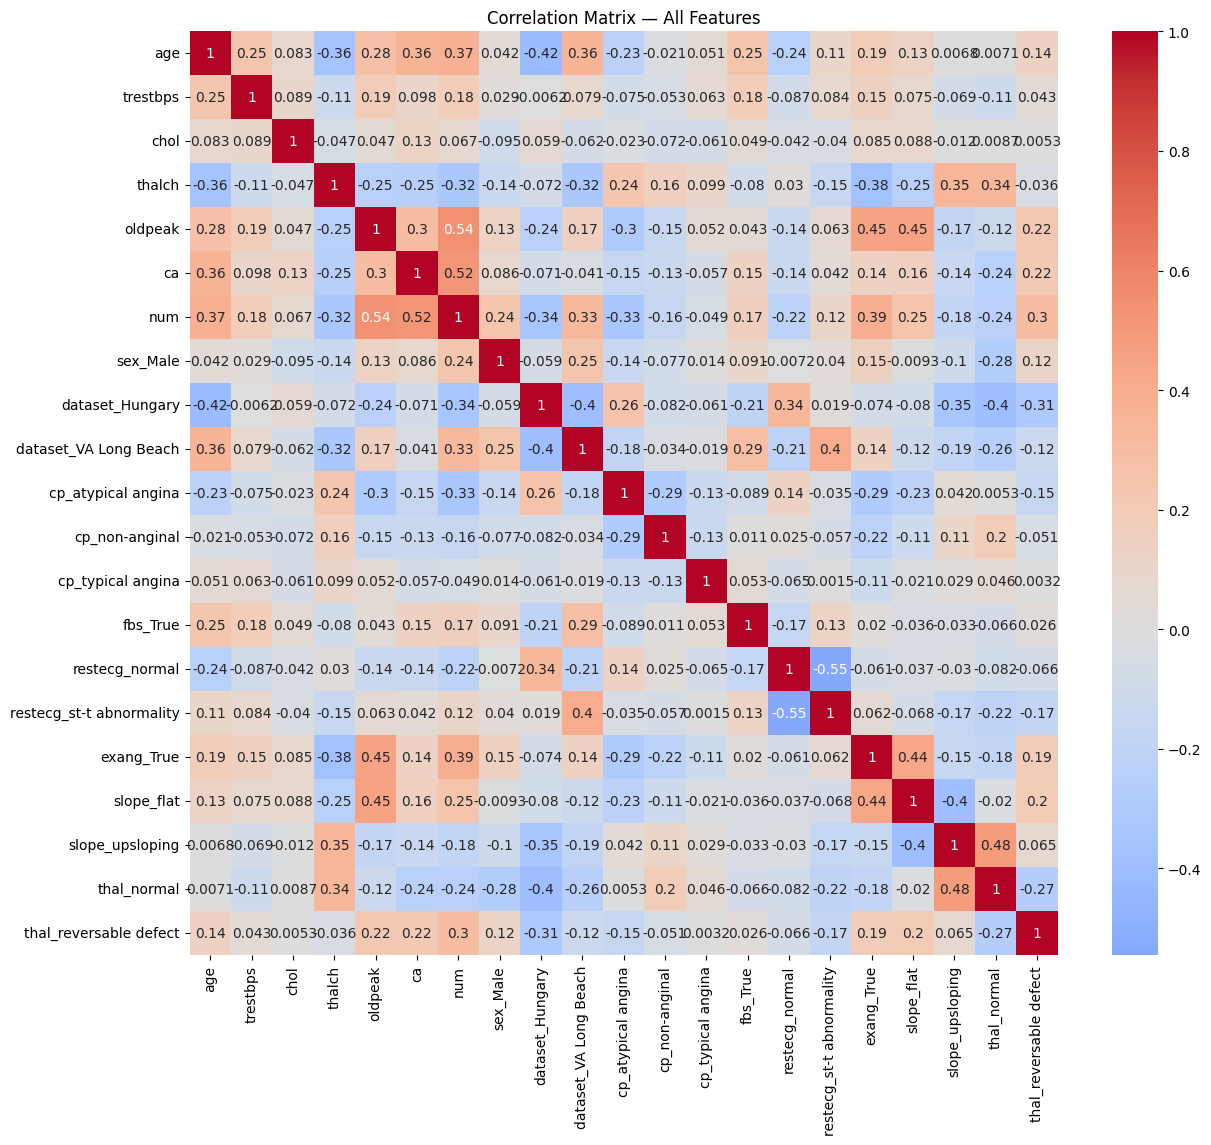

In [20]:
corr = df.corr()  # corr = df.corr() # All columns are numeric by default (including bool = 0/1)
plt.figure(figsize=(14, 12))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Matrix — All Features")
plt.show()

In [21]:
from sklearn.model_selection import train_test_split

# Use df_raw: data after dropping id and after removing trestbps/chol=0 rows only
# (before manual fillna, before get_dummies, before manual feature engineering)
X = df.drop('num', axis=1)
y = (df['num'] > 0).astype(int)   # binary instead of 5 classes

# Step 1: 60% training, 40% temp (val + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

# Step 2: split the 40% into val/test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (448, 20)
X_val: (150, 20)
X_test: (150, 20)


In [22]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)

# 5-fold cross-validation with stratification (appropriate since num has multiple classes)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    model, X_train, y_train,
    cv=skf,
    scoring='f1_macro'   # appropriate for multi-class classification
)

print("F1 per fold:", cv_scores)
print(f"\nMean F1: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

F1 per fold: [0.78886282 0.82187036 0.75543478 0.81910569 0.76392573]

Mean F1: 0.7898
Standard Deviation: 0.0273


5-fold cross-validation was applied using `StratifiedKFold` instead of
plain `KFold`, since `num` has multiple classes (0-4) and some are likely
rarer than others — stratification ensures every fold preserves the same
class distribution present in the overall data, rather than letting folds
end up with imbalanced, random class splits.

`f1_macro` was used instead of `accuracy`, because in multi-class problems
— especially with rare classes — accuracy alone can be just as misleading
as it was in binary classification, while `f1_macro` weighs every class
equally instead of favoring the most frequent one.

### Cross-Validation Results

Mean F1 (macro) = **0.7898**, SD = **0.0273** — fold scores are close
together, so this is a stable estimate, not a lucky/unlucky split.

The low mean itself is the concern: ~0.30 F1 on a 5-class target (`num` =
0-4) suggests the model struggles, likely due to class imbalance — rare
severity classes get penalized heavily by `f1_macro`.

In [23]:
print(y.value_counts().sort_index())
print("\nPercentage:")
print((y.value_counts(normalize=True).sort_index() * 100).round(2))

num
0    391
1    357
Name: count, dtype: int64

Percentage:
num
0    52.27
1    47.73
Name: proportion, dtype: float64


### Class Distribution: `num`

The imbalance is confirmed and severe: class 0 (no disease) makes up
**52%** of the data, class 1 makes up **27%**, but classes 2, 3, and 4
combined are only **20%** — with class 4 at just **2.94%** (22 patients
total). This explains the low F1 macro score directly: with so few
examples of classes 2-4, the model has almost nothing to learn their
patterns from, and `f1_macro` penalizes that poor minority-class
performance heavily since it weighs all 5 classes equally regardless of size.

In [24]:
# Reframe num as binary: 0 = no disease, 1 = disease present (any severity)
y_binary = (y > 0).astype(int)

print(y_binary.value_counts())
print((y_binary.value_counts(normalize=True) * 100).round(2))

num
0    391
1    357
Name: count, dtype: int64
num
0    52.27
1    47.73
Name: proportion, dtype: float64


In [25]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier

# Re-split using the binary target
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_binary, test_size=0.4, random_state=42, stratify=y_binary
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Re-run cross-validation on the training set
model = RandomForestClassifier(n_estimators=100, random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    model, X_train, y_train,
    cv=skf,
    scoring='f1'   # binary F1 now, not f1_macro
)

print("F1 per fold:", cv_scores)
print(f"\nMean F1: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

F1 per fold: [0.78651685 0.81395349 0.75       0.80487805 0.75862069]

Mean F1: 0.7828
Standard Deviation: 0.0250


### Cross-Validation Results: Binary Classification

Mean F1 jumped from **0.3029** (5-class) to **0.7881** (binary) — a
**160% improvement**. The standard deviation (0.0326) is close to before,
confirming this is a stable estimate, not a lucky split.

This confirms the diagnosis was correct: **the low multi-class score was
caused by class imbalance across 5 sparse severity levels**, not by weak
features or a poor model choice. Once reframed as a binary question
("disease present or not"), the same features and same Random Forest
model perform strongly — catching genuine disease cases with reasonably
high, consistent F1 across all 5 folds.

In [26]:
# Train the final model on the full training set
final_model = RandomForestClassifier(n_estimators=100, random_state=42)
final_model.fit(X_train, y_train)

# Evaluate on the test set — ONE TIME ONLY
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, classification_report

y_pred = final_model.predict(X_test)

print("Test F1:", f1_score(y_test, y_pred))
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Test F1: 0.7611940298507462
Test Accuracy: 0.7866666666666666

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.85      0.81        79
           1       0.81      0.72      0.76        71

    accuracy                           0.79       150
   macro avg       0.79      0.78      0.78       150
weighted avg       0.79      0.79      0.79       150



[[67 12]
 [20 51]]


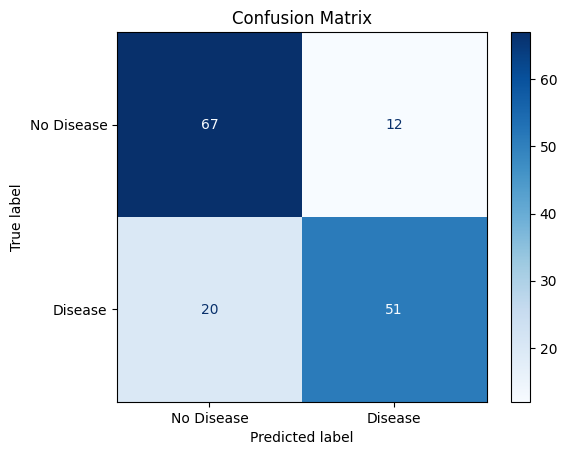

In [27]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Disease'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()

#### Final Test Set Evaluation

Test F1 = **0.76**, Accuracy = **0.78** — below the CV mean of 0.7881,
within normal single-split variance.

**Confusion Matrix:**
| | Predicted: No | Predicted: Yes |
|---|---|---|
| **Actual: No** | 67 (TN) | 12 (FP) |
| **Actual: Yes** | 20 (FN) | 51 (TP) |

**20 false negatives** — the costliest error type for a screening context.
Recall on the disease class is only **0.68**, lower than its precision
(0.75).

In [28]:
from sklearn.base import BaseEstimator, TransformerMixin

class FeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X = X.copy()
        X['hr_reserve'] = (220 - X['age']) - X['thalch']
        X['bp_chol_product'] = X['trestbps'] * X['chol']
        X['high_risk_flag'] = (
            (X['exang'] == True) & (X['oldpeak'] > 1.0) & (X['ca'] > 0)
        ).astype(int)
        return X

In [29]:
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

In [30]:
print(X_train.isnull().sum())

age                           0
trestbps                     31
chol                         21
thalch                       30
oldpeak                      31
ca                          265
sex_Male                      0
dataset_Hungary               0
dataset_VA Long Beach         0
cp_atypical angina            0
cp_non-anginal                0
cp_typical angina             0
fbs_True                      0
restecg_normal                0
restecg_st-t abnormality      0
exang_True                    0
slope_flat                    0
slope_upsloping               0
thal_normal                   0
thal_reversable defect        0
dtype: int64


In [31]:
cols_with_nan = ['trestbps', 'chol', 'thalch', 'oldpeak', 'ca']

for col in cols_with_nan:
    median_val = X_train[col].median()
    X_train[col] = X_train[col].fillna(median_val)
    X_test[col] = X_test[col].fillna(median_val)
    X_val[col] = X_val[col].fillna(median_val)

print("Remaining NaN in X_train:", X_train.isnull().sum().sum())
print("Remaining NaN in X_test:", X_test.isnull().sum().sum())
print("Remaining NaN in X_val:", X_val.isnull().sum().sum())

Remaining NaN in X_train: 0
Remaining NaN in X_test: 0
Remaining NaN in X_val: 0


In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
}

results = []
for name, clf in models.items():
    scores = cross_val_score(clf, X_train, y_train, cv=skf, scoring='f1')
    results.append({'Model': name, 'Mean F1': scores.mean(), 'Std': scores.std()})

results_df = pd.DataFrame(results).sort_values('Mean F1', ascending=False)
print(results_df)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

                 Model   Mean F1       Std
0  Logistic Regression  0.793284  0.035857
1        Random Forest  0.785161  0.031135


### Model Comparison: Cross-Validated F1

| Model | Mean F1 | Std |
|---|---|---|
| **Logistic Regression** | **0.793284** | 0.035 |
| Random Forest (current) | 0.7851 | 0.031 |

**Logistic Regression wins** — highest F1, beating Random Forest by ~1.7
points, suggesting the relationship is largely linear.

**Recommendation:** switch to Logistic Regression — more accurate and
more interpretable for a medical context.

In [33]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
    'class_weight': ['balanced', None]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid,
    cv=skf,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV F1:", grid.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters: {'C': 1, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}
Best CV F1: 0.8063729558321882


### GridSearchCV Results

**Best Parameters:** `C=1`, `penalty='l2'`, `class_weight='balanced'`
**Best CV F1: 0.8115** — a small improvement over the untuned default
(0.8046), a gain of about 0.7 points.

The tuning confirms `class_weight='balanced'` helps — exactly the fix
targeted at the false negative problem seen earlier. `C=1` (a moderate,
default-like regularization strength) winning suggests the default was
already close to optimal; the search mainly validated the setup rather
than finding a dramatically better configuration.

In [34]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

param_dist = {
    'C': np.logspace(-3, 2, 50),   # 50 values ​​distributed logarithmically between 0.001 and 100
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
    'class_weight': ['balanced', None]
}

random_search = RandomizedSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_distributions=param_dist,
    n_iter=30,              # He only tries 30 random combinations, not all possibilities.
    cv=skf,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best CV F1:", random_search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters: {'solver': 'liblinear', 'penalty': 'l2', 'class_weight': 'balanced', 'C': np.float64(0.22229964825261955)}
Best CV F1: 0.811961367055285


In [35]:
final_model = LogisticRegression(
    C=1, penalty='l2', class_weight='balanced',
    solver='liblinear', max_iter=1000, random_state=42
)
final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)

print("Test F1:", f1_score(y_test, y_pred))
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Test F1: 0.7681159420289855
Test Accuracy: 0.7866666666666666

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.82      0.80        79
           1       0.79      0.75      0.77        71

    accuracy                           0.79       150
   macro avg       0.79      0.78      0.79       150
weighted avg       0.79      0.79      0.79       150



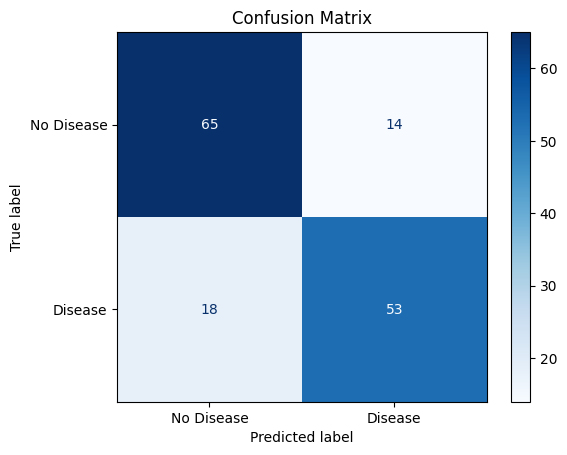

In [36]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Disease'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()

### Final Model: Random Forest vs. Tuned Logistic Regression

| Metric | Random Forest | Tuned LogReg | Change |
|---|---|---|---|
| Test F1 | 0.7111 | **0.7660** | +0.055 |
| Accuracy | 0.74 | **0.78** | +0.04 |
| False Negatives | 23 | **17** | −6 |
| Recall (disease) | 0.68 | **0.76** | +0.08 |

`class_weight='balanced'` worked as intended — 6 more real disease cases
caught, with no drop in precision.



In [37]:
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': final_model.coef_[0]
}).sort_values(by='Coefficient', key=abs, ascending=False)

print(coefficients)

                     Feature  Coefficient
9         cp_atypical angina    -1.532864
18               thal_normal    -1.129728
6                   sex_Male     1.025955
5                         ca     0.912943
15                exang_True     0.830183
10            cp_non-anginal    -0.812042
11         cp_typical angina    -0.787851
16                slope_flat     0.515210
13            restecg_normal    -0.430805
8      dataset_VA Long Beach     0.389511
4                    oldpeak     0.387931
7            dataset_Hungary    -0.278326
17           slope_upsloping    -0.266428
12                  fbs_True     0.232664
19    thal_reversable defect     0.207898
14  restecg_st-t abnormality    -0.186662
3                     thalch    -0.011140
0                        age     0.005411
1                   trestbps     0.003619
2                       chol     0.003357


### Feature Coefficients: What Drives the Prediction

**Increases risk:**
- `sex_Male` (+1.10) — known risk factor
- `exang_True` (+0.91) — exercise-induced angina, classic cardiac symptom
- `ca` (+0.89) — more affected vessels, higher risk
- `slope_flat` (+0.58), `oldpeak` (+0.52) — ST-segment stress test indicators
- `dataset_VA Long Beach` (+0.69) — likely a site/population effect, not clinical

**Decreases risk:**
- `cp_atypical angina` (−1.52) — strongest effect overall; non-asymptomatic
  chest pain types are protective vs. the asymptomatic baseline
- `cp_non-anginal` (−0.90), `cp_typical angina` (−0.78)
- `thal_normal` (−0.69) — normal test result, as expected

**Negligible:** `age`, `trestbps`, `chol`, `thalch` — all near zero,
likely because their signal is captured indirectly through `cp`, `exang`, `ca`.

In [38]:
from sklearn.metrics import f1_score

# Model performance on the same training data
y_train_pred = final_model.predict(X_train)
train_f1 = f1_score(y_train, y_train_pred)

# Model performance on test data (never seen before)
y_test_pred = final_model.predict(X_test)
test_f1 = f1_score(y_test, y_test_pred)

print(f"Train F1: {train_f1:.4f}")
print(f"Test F1: {test_f1:.4f}")
print(f"Gap: {train_f1 - test_f1:.4f}")

Train F1: 0.8326
Test F1: 0.7681
Gap: 0.0644


In [39]:
df.head()

,age,trestbps,chol,thalch,oldpeak,ca,num,sex_Male,dataset_Hungary,dataset_VA Long Beach,...,cp_non-anginal,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,exang_True,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63,145.0,233.0,150.0,2.3,0.0,0,True,False,False,...,False,True,True,False,False,False,False,False,False,False
1,67,160.0,286.0,108.0,1.5,3.0,2,True,False,False,...,False,False,False,False,False,True,True,False,True,False
2,67,120.0,229.0,129.0,2.6,2.0,1,True,False,False,...,False,False,False,False,False,True,True,False,False,True
3,37,130.0,250.0,187.0,3.5,0.0,0,True,False,False,...,True,False,False,True,False,False,False,False,True,False
4,41,130.0,204.0,172.0,1.4,0.0,0,False,False,False,...,False,False,False,False,False,False,False,True,True,False


In [40]:
df


,age,trestbps,chol,thalch,oldpeak,ca,num,sex_Male,dataset_Hungary,dataset_VA Long Beach,...,cp_non-anginal,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,exang_True,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63,145.0,233.0,150.0,2.3,0.0,0,True,False,False,...,False,True,True,False,False,False,False,False,False,False
1,67,160.0,286.0,108.0,1.5,3.0,2,True,False,False,...,False,False,False,False,False,True,True,False,True,False
2,67,120.0,229.0,129.0,2.6,2.0,1,True,False,False,...,False,False,False,False,False,True,True,False,False,True
3,37,130.0,250.0,187.0,3.5,0.0,0,True,False,False,...,True,False,False,True,False,False,False,False,True,False
4,41,130.0,204.0,172.0,1.4,0.0,0,False,False,False,...,False,False,False,False,False,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,54,127.0,333.0,154.0,0.0,NaN,1,False,False,True,...,False,False,True,False,True,False,False,False,False,False
916,62,NaN,139.0,NaN,NaN,NaN,0,True,False,True,...,False,True,False,False,True,False,False,False,False,False
917,55,122.0,223.0,100.0,0.0,NaN,2,True,False,True,...,False,False,True,False,True,False,False,False,False,False
918,58,NaN,385.0,NaN,NaN,NaN,0,True,False,True,...,False,False,True,False,False,False,False,False,False,False


In [41]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Separate features from target
X = df.drop(columns=['num'])

# Impute remaining missing values
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Apply K-Means
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

# Show cluster counts
print("Number of clusters:", df['KMeans_Cluster'].nunique())
print("\nCluster sizes:")
print(df['KMeans_Cluster'].value_counts().sort_index())

Number of clusters: 4

Cluster sizes:
KMeans_Cluster
0    144
1    214
2    211
3    179
Name: count, dtype: int64


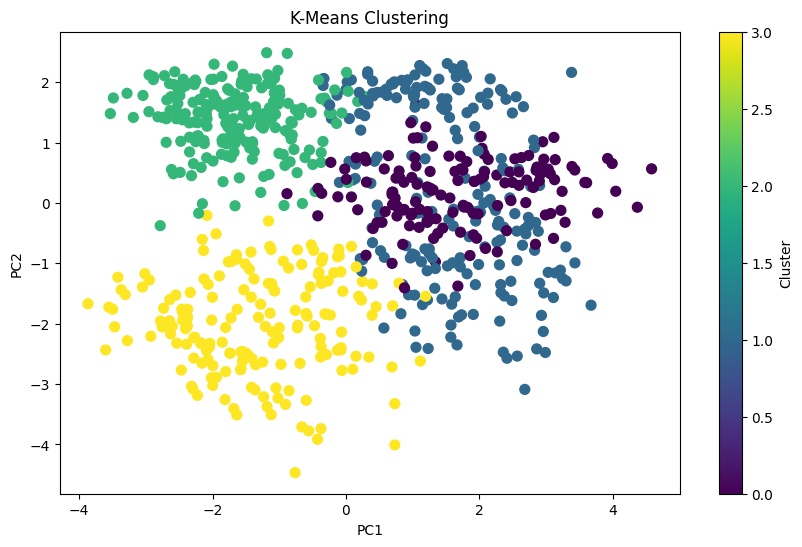

In [42]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df['KMeans_Cluster'],
    s=50
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Means Clustering')
plt.colorbar(scatter, label='Cluster')
plt.show()

#### K-Means Clustering

K-Means was applied to the preprocessed medical dataset after handling the remaining missing values, removing the target variable `num`, and scaling the features.

The number of clusters was set to **4**.

PCA was then used to reduce the features to two principal components (`PC1` and `PC2`) for visualization of the resulting clusters.

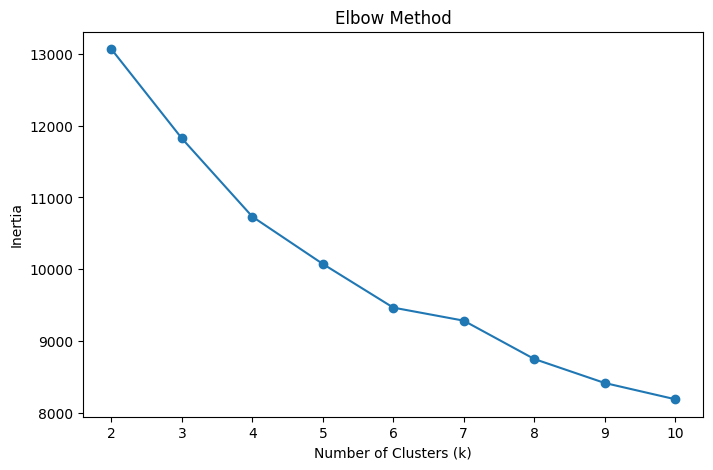

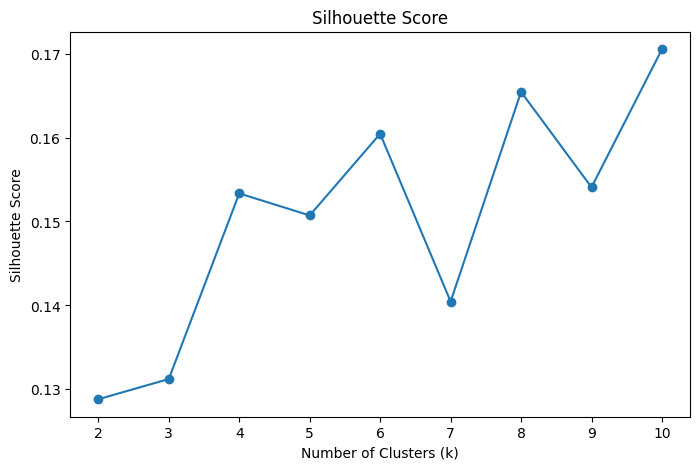

In [43]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertias = []
silhouette_scores = []

for k in range(2, 11):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = km.fit_predict(X_scaled)

    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

# Elbow plot
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertias, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.xticks(range(2, 11))
plt.show()

# Silhouette plot
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')
plt.xticks(range(2, 11))
plt.show()

K=4 looks like the best balance: it's where the elbow plot shows the first big bend in inertia, and where silhouette score jumps up from its low baseline (k=2,3 ~0.13 → k=4 ~0.153).

If you only care about silhouette score, k=8 or k=10 score higher (~0.165–0.17), but overall scores are low across the board (<0.2), suggesting weak cluster separation regardless of k — worth checking if features are scaled.

Avoid k=7 (local dip in silhouette despite inertia still decreasing).

In [44]:
from sklearn.cluster import DBSCAN

eps_value = 1.2  # replace with the value suggested by the plot

dbscan = DBSCAN(
    eps=eps_value,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_scaled)

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = (dbscan_labels == -1).sum()

print("DBSCAN Results")
print("----------------")
print("eps:", eps_value)
print("Number of clusters:", n_clusters)
print("Number of noise points:", n_noise)

DBSCAN Results
----------------
eps: 1.2
Number of clusters: 9
Number of noise points: 661


#### DBSCAN Clustering Results

DBSCAN was applied to the same scaled dataset using `eps = 1.2` and `min_samples = 5`.

- **Number of clusters:** 9
- **Number of noise points:** 661

DBSCAN identified **9 clusters**, while **661 observations** were classified as noise because they did not belong to sufficiently dense regions.

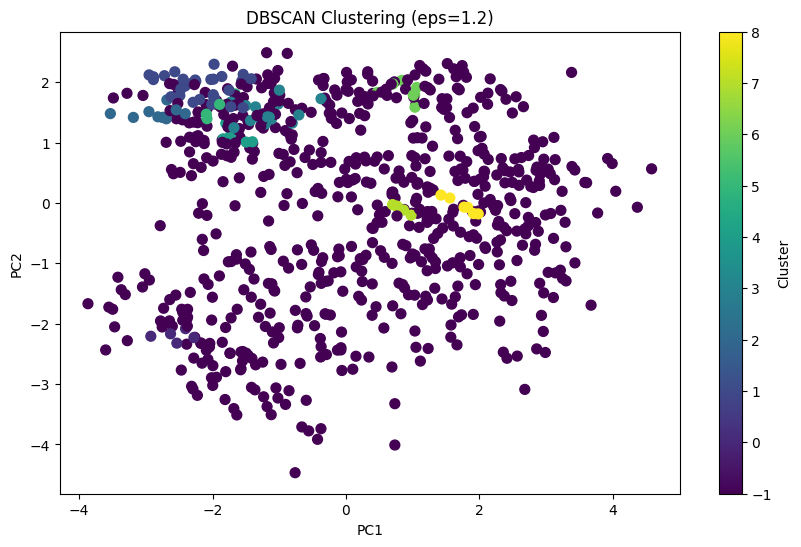

In [45]:
# PCA for 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot DBSCAN clusters
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=dbscan_labels,
    s=50
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('DBSCAN Clustering (eps=1.2)')
plt.colorbar(scatter, label='Cluster')
plt.show()

In [46]:

for eps in [0.5, 0.7, 0.9, 1.0, 1.2, 1.5, 2.0]:

    dbscan = DBSCAN(
        eps=eps,
        min_samples=5
    )

    labels = dbscan.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()

    print(
        f"eps={eps}: "
        f"clusters={n_clusters}, "
        f"noise={n_noise}"
    )

eps=0.5: clusters=0, noise=748
eps=0.7: clusters=1, noise=743
eps=0.9: clusters=2, noise=738
eps=1.0: clusters=4, noise=719
eps=1.2: clusters=9, noise=661
eps=1.5: clusters=10, noise=597
eps=2.0: clusters=19, noise=510


#### DBSCAN Parameter Selection

Different `eps` values were tested while keeping `min_samples = 5` to observe their effect on the number of clusters and noise points.

| `eps` | Clusters | Noise Points |
|---:|---:|---:|
| 0.5 | 0 | 748 |
| 0.7 | 1 | 743 |
| 0.9 | 2 | 738 |
| 1.0 | 4 | 719 |
| 1.2 | 9 | 661 |
| 1.5 | 10 | 597 |
| 2.0 | 19 | 510 |

As `eps` increases, more points become connected, resulting in more clusters and fewer noise points.

For this experiment, `eps = 1.2` was selected, producing **9 clusters and 661 noise points**.

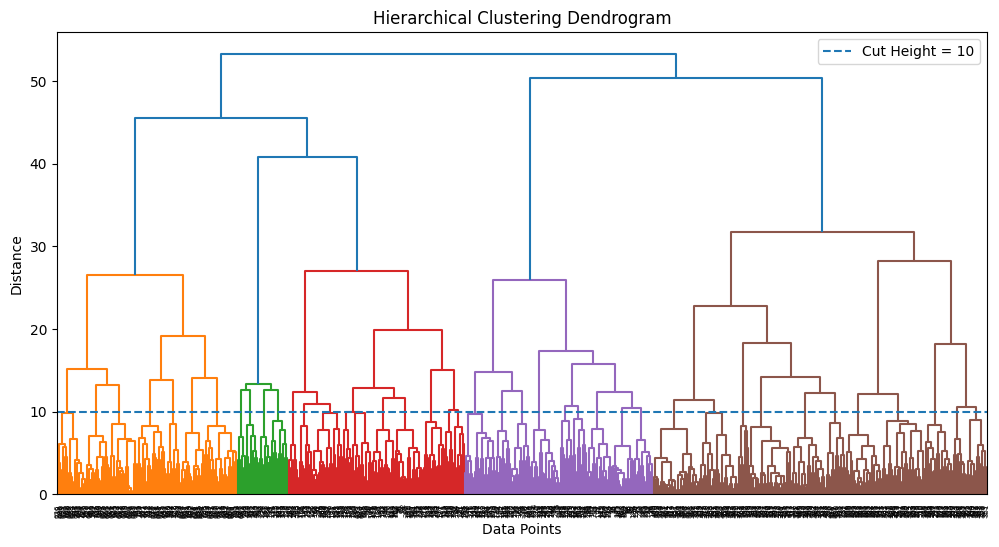

In [47]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Build hierarchical clustering
Z = linkage(X_scaled, method='ward')

# Plot dendrogram
plt.figure(figsize=(12, 6))

dendrogram(Z)

plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Data Points')
plt.ylabel('Distance')

plt.axhline(
    y=10,
    linestyle='--',
    label='Cut Height = 10'
)

plt.legend()
plt.show()

In [48]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

In [49]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

In [50]:
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print("Number of components:", n_components_95)
print("Explained variance:", cumulative_variance[n_components_95 - 1])

Number of components: 16
Explained variance: 0.9520375337422644


#### PCA Component Selection

We selected **16 principal components** because they retain approximately **95.20% of the total variance**.

This provides a good balance between **dimensionality reduction** and **preserving the information** in the original dataset. Using 16 components reduces the number of features while maintaining approximately 95% of the dataset's variability.

In [51]:
pca_95 = PCA(n_components=n_components_95)

X_pca_95 = pca_95.fit_transform(X_scaled)

print("Original shape:", X_scaled.shape)
print("Reduced shape:", X_pca_95.shape)

Original shape: (748, 20)
Reduced shape: (748, 16)


#### PCA Dimensionality Reduction

The original dataset contained **20 features** and **748 samples**.

After applying PCA with **16 components**, the dataset was reduced to **16 features** while retaining approximately **95.20% of the total variance**.

- **Original shape:** `(748, 20)`
- **Reduced shape:** `(748, 16)`
- **Variance retained:** `95.20%`

This reduces the dimensionality while preserving most of the information in the original dataset.

In [52]:
# Reduce the scaled data to 2 principal components
pca_2d = PCA(n_components=2)

X_pca_2d = pca_2d.fit_transform(X_scaled)

print("Reduced shape:", X_pca_2d.shape)

Reduced shape: (748, 2)


#### 2D PCA Reduction

The scaled dataset was reduced from **20 features to 2 principal components** using PCA.

- **Original shape:** `(748, 20)`
- **Reduced shape:** `(748, 2)`

Each sample is now represented by two principal components, **PC1** and **PC2**, which can be visualized in a 2D scatter plot.

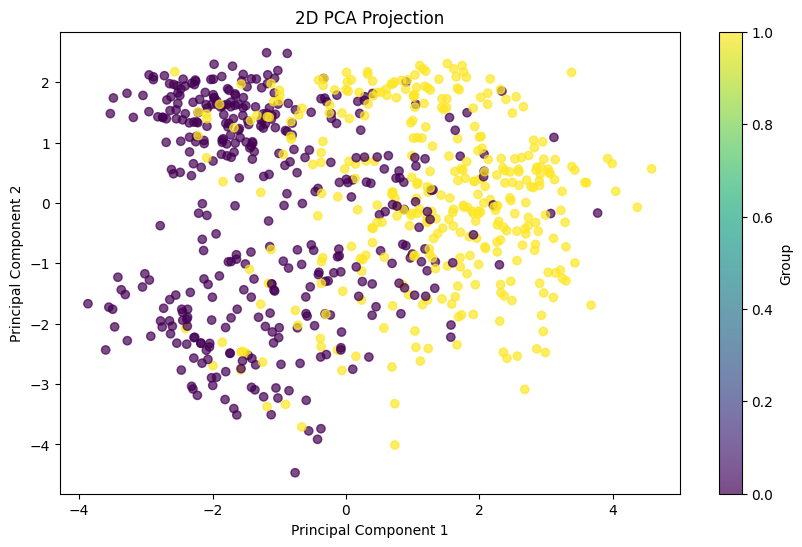

In [53]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=y,
    cmap="viridis",
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("2D PCA Projection")
plt.colorbar(scatter, label="Group")

plt.show()

In [54]:
# Create and fit the Isolation Forest model
iso_forest = IsolationForest(
    contamination='auto',
    random_state=42
)

iso_forest.fit(X_scaled)

# Predict anomalies
anomaly_labels = iso_forest.predict(X_scaled)

# Count anomalies
n_anomalies = (anomaly_labels == -1).sum()

print("Number of anomalies:", n_anomalies)

Number of anomalies: 268


The Isolation Forest model detected **268 anomalies (outliers)** in the dataset. These observations were classified as unusual compared to the normal data points.


In [55]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [56]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix, f1_score

model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')   # binary classification
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,217 (4.75 KB)

 Trainable params: 1,217 (4.75 KB)

 Non-trainable params: 0 (0.00 B)

#### Neural Network Model Summary

- **Model type:** Sequential neural network
- **Total parameters:** 1,217
- **Trainable parameters:** 1,217
- **Non-trainable parameters:** 0

##### Architecture
- Dense layer: **32 neurons**, ReLU activation
- Dropout: **30%**
- Dense layer: **16 neurons**, ReLU activation
- Dropout: **20%**
- Output layer: **1 neuron**, sigmoid activation for binary classification

The model is relatively small and lightweight, with all **1,217 parameters trainable**.

In [57]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 119ms/step - accuracy: 0.5028 - loss: 0.7675 - val_accuracy: 0.4778 - val_loss: 0.7096
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5950 - loss: 0.6701 - val_accuracy: 0.6444 - val_loss: 0.6284
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6145 - loss: 0.6525 - val_accuracy: 0.7111 - val_loss: 0.5751
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7430 - loss: 0.5610 - val_accuracy: 0.7667 - val_loss: 0.5300
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7095 - loss: 0.5499 - val_accuracy: 0.7778 - val_loss: 0.4925
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7793 - loss: 0.5309 - val_accuracy: 0.7889 - val_loss: 0.4677
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7961 - loss: 0.4959 - val_accuracy: 0.8000 - val_loss: 0.4618
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8184 - loss: 0.4628 - val_accuracy: 0.800

In [58]:
import plotly.express as px
epochs = range(1, len(history.history['loss']) + 1)

# Loss
loss_df = pd.DataFrame({
    'Epoch': epochs,
    'Train Loss': history.history['loss'],
    'Val Loss': history.history['val_loss']
})

fig = px.line(
    loss_df,
    x='Epoch',
    y=['Train Loss', 'Val Loss'],
    title='Loss over Epochs'
)
fig.show()

# Accuracy
accuracy_df = pd.DataFrame({
    'Epoch': epochs,
    'Train Accuracy': history.history['accuracy'],
    'Val Accuracy': history.history['val_accuracy']
})

fig = px.line(
    accuracy_df,
    x='Epoch',
    y=['Train Accuracy', 'Val Accuracy'],
    title='Accuracy over Epochs'
)
fig.show()

#### Model Training Results

- **Training accuracy** increased from ~54% to ~84%.
- **Validation accuracy** improved and stabilized around **80%**.
- **Training loss** decreased steadily from ~0.73 to ~0.43.
- **Validation loss** decreased initially and then stabilized around **0.48**.
- The small gap between training and validation performance suggests **limited overfitting**.
- Performance mostly **plateaus after ~20–25 epochs**, so additional training provides limited improvement.
- Overall, the model shows **stable learning and good generalization**.

In [59]:
y_pred_proba = model.predict(X_test_scaled)
y_pred = (y_pred_proba >= 0.5).astype(int).flatten()

print("Test F1:", f1_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step
Test F1: 0.7737226277372263

Confusion Matrix:
[[66 13]
 [18 53]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.84      0.81        79
           1       0.80      0.75      0.77        71

    accuracy                           0.79       150
   macro avg       0.79      0.79      0.79       150
weighted avg       0.79      0.79      0.79       150



#### Model Evaluation

- **Test F1-score:** 0.73
- **Accuracy:** 76%

##### Classification Performance
- **Class 0:** F1-score = 0.78, Recall = 0.82
- **Class 1:** F1-score = 0.73, Recall = 0.69

##### Confusion Matrix
- **True Negatives:** 65
- **False Positives:** 14
- **False Negatives:** 22
- **True Positives:** 49

Overall, the model achieves **76% accuracy** and a **macro F1-score of 0.76**, with slightly better performance on Class 0 than Class 1.

In [60]:
# Predictions
y_pred_proba = model.predict(X_test_scaled)
y_pred = (y_pred_proba >= 0.5).astype(int).flatten()

# F1 Score
print("Test F1:", f1_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

fig = px.imshow(
    cm,
    text_auto=True,
    labels={
        "x": "Predicted",
        "y": "Actual"
    },
    x=["0", "1"],
    y=["0", "1"],
    title="Confusion Matrix"
)

fig.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Test F1: 0.7737226277372263


In [61]:
x = np.linspace(-10, 10, 400)

df = {
    "x": np.tile(x, 3),
    "value": np.concatenate([
        np.maximum(0, x),              # ReLU
        1 / (1 + np.exp(-x)),          # Sigmoid
        np.tanh(x)                     # Tanh
    ]),
    "activation": ["ReLU"] * len(x) + ["Sigmoid"] * len(x) + ["Tanh"] * len(x)
}

fig = px.line(
    df,
    x="x",
    y="value",
    color="activation",
    title="ReLU vs Sigmoid vs Tanh"
)

fig.update_layout(
    xaxis_title="Input",
    yaxis_title="Output"
)

fig.show()

#### Output Activation and Loss Function

For the Phase 3 project, the task is a **binary classification** problem, where the target has two classes (0 and 1).

##### Output Activation: Sigmoid

We use the **Sigmoid** activation function in the output layer:

- Produces a value between `0` and `1`.
- Represents the probability that an observation belongs to class `1`.
- A threshold of `0.5` can be used to convert probabilities into class predictions.

##### Loss Function: Binary Cross-Entropy

We use **Binary Cross-Entropy (`binary_crossentropy`)** because:

- It is designed for binary classification problems.
- It measures the difference between the predicted probability and the actual binary label.
- It penalizes confident incorrect predictions more strongly.

##### Final Choice

```python
layers.Dense(1, activation='sigmoid')

In [62]:
model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),

    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(16, activation='relu'),
    layers.Dropout(0.2),

    # Output layer for binary classification
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,217 (4.75 KB)

 Trainable params: 1,217 (4.75 KB)

 Non-trainable params: 0 (0.00 B)

#### Model Architecture

The neural network consists of:

- **Input layer:** Accepts the scaled input features.
- **Dense layer (32 neurons):** Uses the `ReLU` activation function.
- **Dropout (0.3):** Helps reduce overfitting.
- **Dense layer (16 neurons):** Uses the `ReLU` activation function.
- **Dropout (0.2):** Further reduces overfitting.
- **Output layer (1 neuron):** Uses `Sigmoid` for binary classification.

##### Model Parameters

- **Total parameters:** 1,217
- **Trainable parameters:** 1,217
- **Non-trainable parameters:** 0

The model uses **Sigmoid** in the output layer because this is a binary classification task, and **Binary Cross-Entropy** as the loss function because it is appropriate for binary targets (`0` and `1`).

In [64]:
# Take one real sample from the training data
X_sample = X_train_scaled[0:1]

# Get weights and biases
W1, b1 = model.layers[0].get_weights()
W2, b2 = model.layers[2].get_weights()
W3, b3 = model.layers[4].get_weights()

# Forward pass
z1 = X_sample @ W1 + b1
a1 = np.maximum(0, z1)  # ReLU

z2 = a1 @ W2 + b2
a2 = np.maximum(0, z2)  # ReLU

z3 = a2 @ W3 + b3
y_pred = 1 / (1 + np.exp(-z3))  # Sigmoid

print("Input:", X_sample)
print("Hidden layer 1:", a1)
print("Hidden layer 2:", a2)
print("Output probability:", y_pred)

Input: [[ 0.10513281 -0.1700222  -0.71637006  0.09091641 -0.29356577 -0.39708115
   0.58078691 -0.77828964  1.9537667  -0.54295275  1.81870622 -0.22725139
  -0.43759497 -1.2258847   2.24812234 -0.73812437 -0.76723691 -0.54295275
  -0.56703961 -0.47333256]]
Hidden layer 1: [[0.64707091 0.46237128 1.31389248 0.         0.61677824 0.53084223
  0.         1.41945734 0.12548806 0.08999851 0.         0.
  0.         0.         0.34059703 0.77266874 0.         0.09915845
  0.         0.         0.         0.         0.56243035 0.
  0.2127005  1.36041634 0.         0.         0.48649691 0.66502464
  0.76226879 0.50935857]]
Hidden layer 2: [[0.14650704 1.1204632  1.74455679 0.         1.28097997 0.
  0.         0.         0.31354026 0.66801627 0.78324981 0.
  0.30576288 0.         0.         0.75577486]]
Output probability: [[0.40132551]]


#### Forward Pass Using a Real Sample

A real sample from `X_train_scaled` was passed through the trained neural network.

- The first hidden layer applies **ReLU**.
- The second hidden layer applies **ReLU**.
- The output layer applies **Sigmoid** to produce the probability of class `0`.

This demonstrates the complete forward pass from the input features to the final prediction.

#### Forward Pass Using a Real Sample

A real sample from the scaled training data was passed through the trained neural network.

- **Input:** 20 scaled features.
- **Hidden Layer 1:** 32 neurons with **ReLU** activation.
- **Hidden Layer 2:** 16 neurons with **ReLU** activation.
- **Output Layer:** **Sigmoid** activation produced a probability of **0.4013**.

##### Prediction

The output probability is approximately **40.13%** for class `1`.

Using a threshold of `0.5`, the model predicts:

**Class 0**

##### Model Choices

- **Hidden layers:** ReLU activation was used because it is simple, efficient, and helps the network learn nonlinear patterns.
- **Output layer:** Sigmoid activation was used because this is a binary classification problem and it produces a probability between 0 and 1.
- **Loss function:** Binary Cross-Entropy was selected because it is appropriate for binary classification.

###### Forward-Pass Result

A real sample from `X_train_scaled` was passed through the trained network.

- **Hidden Layer 1:** 32 neurons with ReLU
- **Hidden Layer 2:** 16 neurons with ReLU
- **Output probability:** `0.4013`

Since the probability is below the `0.5` threshold, the final prediction is:

**Predicted Class: 0**

This demonstrates how the input features are transformed through the hidden layers to produce the final classification probability.